# Quantum Annealing: Noisy Simulation

This notebook introduces a simple coefficient noise model and illustrates how noise perturbs the annealing spectrum.


In [1]:
import os
import sys

root_path = os.path.abspath(os.path.join(os.getcwd(), '..'))
if root_path not in sys.path:
    sys.path.insert(0, root_path)


import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import eigh
from solver.quantum_solver.dwave_simulator import DwaveSimulator
from problem.ising_problem import IsingProblem
plt.rcParams['figure.figsize'] = (12, 5)
plt.style.use('seaborn-v0_8-darkgrid')


In [2]:
def add_noise_to_ising(h, J, std_dev):
    h_noisy = {i: val + np.random.normal(0, std_dev) for i, val in h.items()}
    J_noisy = {ij: val + np.random.normal(0, std_dev) for ij, val in J.items()}
    return h_noisy, J_noisy

def simulate_noisy_evolution(simulator, h, J, nb_eigenvalues=5, std_dev=0.05, noise_on_init=False):
    # Prepare the annealing schedule
    A_schedule = simulator.annealing_schedule['A']
    B_schedule = simulator.annealing_schedule['B']
    annealing_steps = len(A_schedule)
    
    n_qubits = max(h.keys()) + 1 if h else 0
    eigenvalues_history = []
    base_H_init = simulator.build_Hinit(n_qubits)

    # 2. Boucle d'évolution
    for step in range(annealing_steps):
        A_s = A_schedule[step]
        B_s = B_schedule[step]
        
        h_n, J_n = add_noise_to_ising(h, J, std_dev)
        
    
        terms = []
        for i, val in h_n.items():
            terms.append(f"({val})*s{i}")
        for (i, j), val in J_n.items():
            terms.append(f"({val})*s{i}*s{j}")
        
        combined_string = " + ".join(terms)
        
        prob_obj = IsingProblem(string=combined_string)
        H_problem_noisy = simulator.build_Hfinal(prob_obj.expr, n_qubits)
    
        
        H_init = base_H_init
        if noise_on_init:
            noise_matrix = np.diag(np.random.normal(0, std_dev, 2**n_qubits))
            H_init = base_H_init + noise_matrix

        H_total = A_s * H_init + B_s * H_problem_noisy
        
        vals = eigh(H_total, eigvals_only=True, subset_by_index=[0, nb_eigenvalues-1])
        eigenvalues_history.append(vals)

    return np.array(eigenvalues_history)


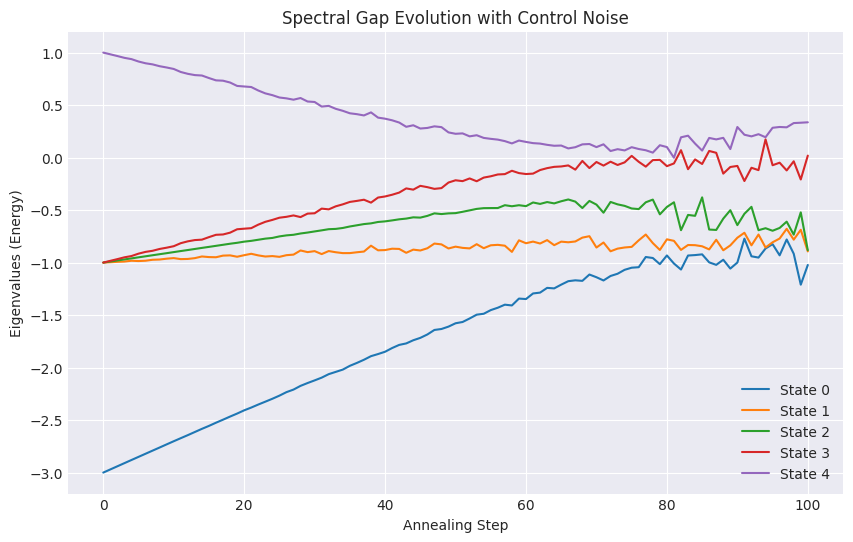

In [3]:
# Initialize a simple three-qubit example
h = {0: 0.1, 1: -0.2, 2: 0.3}
J = {(0, 1): 0.5, (1, 2): -0.4}
simulator = DwaveSimulator() 

# Run a moderate-noise simulation
history = simulate_noisy_evolution(simulator, h, J, std_dev=0.05)

# Plot
plt.figure(figsize=(10, 6))
for i in range(history.shape[1]):
    plt.plot(history[:, i], label=f"State {i}")

plt.title("Spectral Gap Evolution with Control Noise")
plt.xlabel("Annealing Step")
plt.ylabel("Eigenvalues (Energy)")
plt.legend()
plt.show()


The noise is not visible at the beginning of the evolution because the problem Hamiltonian is multiplied by the coefficient B(s), which is zero at s=0. Consequently, the system is entirely dominated by the "clean" initial transverse field Hinit, and the programmed fluctuations have no impact on the initial energy levels.

The noise introduces random fluctuations that make the energy levels appear jagged and unstable throughout the annealing path. This directly affects the Spectral Gap—the energy difference between the ground state (State 0) and the first excited state (State 1)—by potentially forcing these two levels closer together at critical points.